# Statistics Exercises Part 4

This is the fourth of several exercise pages on statistical programming prepared for use in the course **ITSE 1302** at Austin Community College.

See the document titled Statistics Exercises Part 1 for more introductory information.

In previous exercise pages you learned a little about how to use the **hist** method to compute and display a histogram for a dataset. We will revisit the **hist** method in this exercise page and you will learn how to take advantage of several keyword parameters that are available to customize the behavior of the method.

After that, we will look at some examples that demonstrate the *central limit theorem* in action.

## Utility functions

### Normal probabilty density function

Let's begin by defining a function from which you can obtain values for the normal probability density curve for any input values of mu and sigma. See [Engineering Statistics Handbook](http://www.itl.nist.gov/div898/handbook/eda/section3/eda3661.htm) for a definition of the equation for the ***normal probability density function***.

However, this function will be more general than the similar function presented in the earlier exercise pages. The function that was presented in those pages assumed that mu was equal to zero and sigma was equal to 1. Those assumptions result in a function commonly called the ***standard normal distribution***. The following function makes no such assumption and results in the more general ***probability density function***.

As is often the case, we will begin by importing some libraries that will be needed here and at other locations within this turorial.

In [1]:
#Import some libraries that will be needed for this function and for other examples later in the tutorial
import math
from math import pow
import matplotlib.pyplot as plt
from statistics import mean
from statistics import median
from statistics import stdev
import random
import numpy as np

The code for the normalProbabilityDensity follows.

In [2]:
'''
Computes and return values for the normal probabilty density function

required input: x-axis value
optional input: mu
optional input: sigma

returns: The computed value of the function for the given x, mu, and sigma. If mu and sigma are not provided as
input arguments, the method reverts to returning values for the standard normal distribution curve with mu = 0
and sigma = 1.0
'''
def normalProbabilityDensity(x,mu=0,sigma=1.0):
    
    eVal = 2.718281828459045
    exp = -((x-mu)**2)/(2*(sigma**2))
    numerator = pow(eVal,exp)
    denominator = sigma*(math.sqrt(2*math.pi))
    return numerator/denominator

### Cumulative distribution function

Now define a utility function that will return the value of the cumulative normal distribution function. This function takes x as a parameter and returns the area under the standard normal distribution curve from minus infinity up to the value of x.

A call to this function is equivalent to finding a value in a Z-table.

The method for computing the cumulative probability in the following code came from [Stand-alone Python implementation of phi(x) by John D. Cook](https://www.johndcook.com/blog/python_phi/).

See [Standard Normal Probabilities](http://www.stat.ufl.edu/~athienit/Tables/Ztable.pdf) for tables showing the values that should be returned by this function.


In [3]:
'''
Computes and returns values for the cumulative distribution function of the standard normal 
probability density function. Stated differently, computes and returns area under the standard 
normal curve from minus infinity to an input x value.

This is a series implementation. A digital numeric integration version is provided later in 
this document for comparison.

input: x-axis value as a decimal fraction of the standard deviation
returns: The computed value of the function for the given x-axis value

Examples

x = -2, output = 0.022750062887256395
x = -1, output = 0.15865526383236372
x = 0, output = 0.5000000005
x = 1, output = 0.8413447361676363
x = 2, output = 0.9772499371127437

'''
def cumulativeDistribution(x):
    # constants
    a1 =  0.254829592
    a2 = -0.284496736
    a3 =  1.421413741
    a4 = -1.453152027
    a5 =  1.061405429
    p  =  0.3275911

    # Save the sign of x
    sign = 1
    if x < 0:
        sign = -1
    x = abs(x)/math.sqrt(2.0)

    # A&S formula 7.1.26
    t = 1.0/(1.0 + p*x)
    y = 1.0 - (((((a5*t + a4)*t) + a3)*t + a2)*t + a1)*t*math.exp(-x*x)

    return 0.5*(1.0 + sign*y)

#### Test the new function

The following code tests to confirm proper operation of the normalProbabilityDensity function.

xmu = -2
xsigma = 0.59


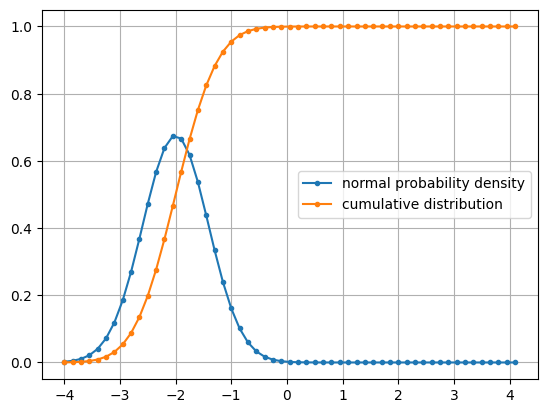

In [4]:
#Plot the normal probability density and the normal probability 
# for the specified values of mu and sigma.
xmu = -2
print("xmu =",xmu)
xsigma = 0.59
print("xsigma =",xsigma)

fig,ax = plt.subplots(1,1)

x = np.arange(-4,4.15,0.15)
y = [normalProbabilityDensity(val,mu=xmu,sigma=xsigma) for val in x]
ax.plot(x,y,label='normal probability density',marker='.')

y = [cumulativeDistribution((val-xmu)/xsigma) for val in x]
ax.plot(x,y,label='cumulative distribution',marker = '.')
ax.grid(True)
ax.legend()
plt.savefig("StatisticsPart04.01.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.01.png**

### Type of Image
Line plot containing two overlaid curves that represent a probability density function and a cumulative distribution function defined over the same x‑axis range.

### Overall Summary
The figure displays two statistical functions plotted together to illustrate how a probability density function and its corresponding cumulative distribution function relate to one another. One curve forms a bell‑shaped distribution centered near x = –2, while the other curve shows the cumulative accumulation of probability, beginning near 0 at x = –4 and rising smoothly toward 1 as x increases.

### Detailed Description
The plot spans an x‑axis ranging from approximately –4 to 4. The y‑axis ranges from 0 to 1. One curve forms a symmetric bell shape that reaches its maximum near x = –2 and decreases toward both ends of the graph. The second curve begins near 0 at the far left of the plot and increases steadily, approaching 1 near the far right. A legend appears in the upper portion of the figure identifying the two curves.

### Purpose of the Image
This image illustrates the relationship between a probability density function and its cumulative distribution function. It supports the introduction and testing of a utility function designed to compute cumulative probabilities, providing a visual reference for how cumulative area corresponds to values typically obtained from a Z‑table.



### A random dataset generator

Now define a utility function that returns a dataset of more or less normally distributed values. The returned dataset is uniformly distributed for an input keyword paramater value of numberSamples=1. The resulting dataset tends more towards normal as the value of numberSamples is increased.

In [5]:
def normalRandomGenerator(seed=1,dataLength=10000,numberSamples=50,lowLim=0,highLim=100):
    '''
    Create a new dataset of dataLength values consisting of the average of numberSamples 
    samples taken from a population of uniformly distributed values between lowLim 
    and highLim generated with a seed of seed.

    Input keyword parameters and their default values:

    seed = 1 seed used to generate the uniformly distributed values
    dataLength = 10000 number of samples in the returned list of values
    numberSamples = 50 number of samples taken from the uniformly distributed population
                       and averaged into the output
    lowLim = 0 lower limit value of the uniformly distributed population
    highLim = 100 high limit value of the uniformly distributed population

    returns: a list containing the dataset

    '''
    data = []
    random.seed(seed)

    for cnt in range(dataLength):
        theSum = 0
        for cnt1 in range(numberSamples):
            theSum += random.uniform(lowLim,highLim)
        data.append(theSum/numberSamples)
        
    return data

## The matplotlib.axes.Axes.hist method

You will probably be using the [matplotlib.axes.Axes.hist](https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.hist.html?highlight=hist#matplotlib.axes.Axes.hist) method from time to time. Therefore, it will be good to learn more about that method.

Let's begin by creating some normally distributed data to experiment with.

In [6]:
# Create a new dataset of 10000 values consisting of the average of 50 samples taken from a population of uniformly
# distributed values between 0 and 100.

data = normalRandomGenerator(dataLength=10000,numberSamples=50)
print("data length =",len(data))
print("mean =",mean(data))
print("standard deviation =",stdev(data))


data length = 10000
mean = 50.00627810855217
standard deviation = 4.106854658585184


### A basic histogram

Now let's compute and display a histogram of the data using the most basic call to the hist method.

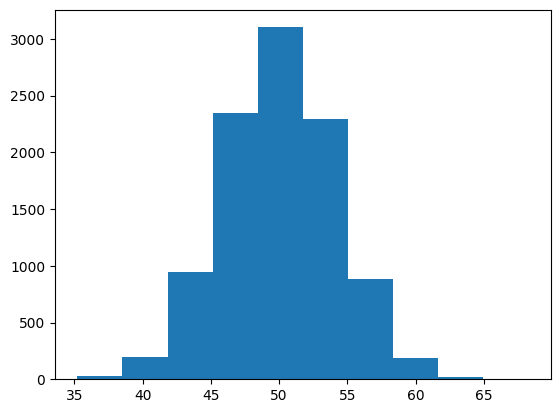

In [7]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist(data)
plt.savefig("StatisticsPart04.02.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.02.png**

### Type of Image
Histogram showing the frequency distribution of a normally generated dataset, plotted using the default behavior of the `matplotlib.axes.Axes.hist` method.

### Overall Summary
The figure displays a histogram of normally distributed data created for the purpose of demonstrating the basic use of the `hist` method in Matplotlib. The distribution forms a clear bell‑shaped pattern centered near a value of 50, with frequencies decreasing symmetrically as values move away from the center. The plot illustrates how the `hist` method bins data and visualizes its distribution without additional styling or parameters.

### Detailed Description
The x‑axis spans values from roughly 35 to 65, and the y‑axis ranges from 0 to about 3500. The histogram consists of nine blue bars that rise to a peak slightly above 3000 near the center of the distribution. The bars decrease in height on both sides, forming a symmetric shape characteristic of a normal distribution. No overlaid curve, gridlines, or annotations appear in the image, and no title is shown. The plot reflects the default appearance produced by a simple call to `Axes.hist`.

### Purpose of the Image
This image demonstrates the most basic usage of the `matplotlib.axes.Axes.hist` method by showing how a normally distributed dataset is rendered when no optional parameters are supplied. It serves as a starting point for learning how histogram settings—such as bin count, density, color, and normalization—affect the visualization of statistical data.

We have a histogram all right, but it is pretty crude. There are only nine bins. The hist method lets us specify the number of bins. Apparently if we don't do that, the default is to compute the histogram with nine bins. 

### Increase bins to 100

Let's tell the hist method to compute and display 100 bins for the same data through the use of the keyword parameter named bins.

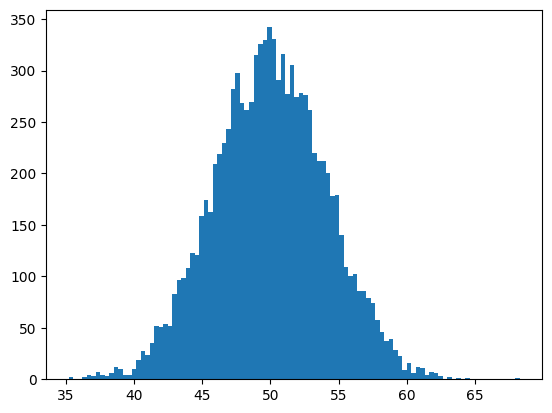

In [8]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100)
plt.savefig("StatisticsPart04.03.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.03.png**

### Type of Image
Histogram showing the distribution of a normally generated dataset, rendered using the `matplotlib.axes.Axes.hist` method with a greatly increased number of bins.

### Overall Summary
The figure displays a histogram of normally distributed data, this time computed using 100 bins instead of the default nine. Increasing the number of bins produces a much more detailed view of the underlying distribution, revealing a relatively smooth bell‑shaped pattern centered near a value of 50. The finer binning reduces the blocky appearance of the earlier histogram and provides a clearer visual approximation of the normal curve.

### Detailed Description
The x‑axis spans values from roughly 35 to 65, and the y‑axis ranges from 0 to about 350. The histogram consists of many narrow blue bars, each representing one of the 100 bins. The bars collectively form a symmetric shape with the highest frequencies near the center of the distribution and steadily decreasing frequencies toward both ends. No overlaid curve, title, or additional annotations appear in the image. The overall effect is a relatively smooth, high‑resolution depiction of the dataset’s normal distribution.

### Purpose of the Image
This image demonstrates how specifying a larger number of bins in the `hist` method produces a more refined and informative histogram. It supports the instructional goal of showing how bin count affects the appearance and interpretability of a histogram, especially when visualizing normally distributed data.

### The vertical axis scale

Can we ascribe any meaning to the numbers on the vertical axis? Let's see what happens if we double the number of data values without materially changing the shape of the distribution. We can do that by concatenating the list containing the data values with an exact copy of itself.

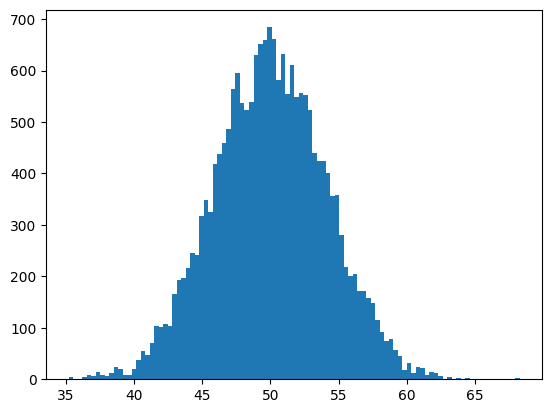

In [9]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist((data + data),bins=100)
plt.savefig("StatisticsPart04.04.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.04.png**

### Type of Image
Histogram showing the distribution of a normally generated dataset after the number of data values has been doubled to illustrate how the vertical axis scale responds to changes in sample size.

### Overall Summary
The figure displays a histogram of normally distributed data in which the dataset has been duplicated and concatenated with itself. This operation preserves the shape and location of the distribution while doubling the total number of observations. As a result, the histogram retains its bell‑shaped form centered near 50, but the bar heights on the vertical axis approximately double, demonstrating that histogram frequencies scale directly with the number of data values.

### Detailed Description
The x‑axis spans values from roughly 35 to 65. The y‑axis extends upward to about 700, with the tallest bars reaching slightly above 650. The histogram consists of many narrow blue bars that collectively form a relatively smooth, symmetric bell shape. The center of the distribution lies near 50, with frequencies decreasing gradually toward both ends. No title, annotations, or overlaid curves appear in the image. The overall shape is identical to the earlier histogram created with half as many data points, but the vertical scale is proportionally larger.

### Purpose of the Image
This image demonstrates that the vertical axis of a histogram reflects raw frequencies, not probabilities or densities. By doubling the number of data values while keeping the distribution unchanged, the histogram’s shape remains the same but the bar heights double. This clarifies how the `hist` method interprets data counts and prepares the reader for later discussions of density normalization and probability‑based histograms.

What we see is that the values on the vertical axis depend on the length of the dataset in addition to the shape of the distribution. That probably isn't what we want to see. Most of the time we are probably interested in seeing the shape of the distribution independent of the length of the dataset.

### The density keyword parameter

The hist method has a boolean keyword parameter (density) that is designed to take care of that issue for us. If this value is set to True, the results are normalized such that the total area under the curve is equal to 1 (more on this later). Let's try it with the original dataset.

Note, the **density** keyword replaced the **normed** keyword from earlier versions.

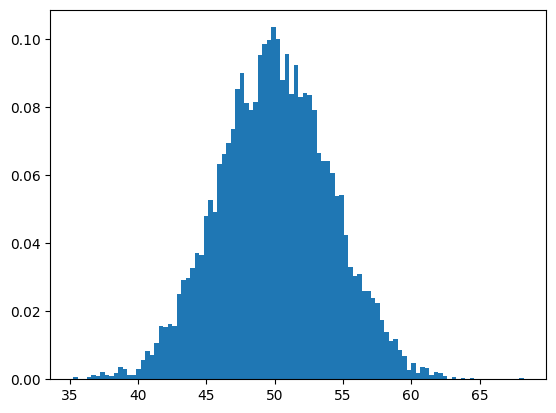

In [10]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist(data,bins=100,density=True)
plt.savefig("StatisticsPart04.05.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.05.png**

### Type of Image
Histogram showing a normalized distribution of a normally generated dataset, produced using the `density=True` keyword parameter of the `matplotlib.axes.Axes.hist` method.

### Overall Summary
The figure displays a histogram of normally distributed data in which the vertical axis has been normalized so that the total area under the bars equals 1. This normalization removes the dependence of bar height on the size of the dataset, allowing the viewer to focus solely on the *shape* of the distribution. The resulting histogram forms a smooth bell‑shaped pattern centered near 50, with relative frequencies expressed as proportions rather than raw counts.

### Detailed Description
The x‑axis spans values from roughly 35 to 65. The y‑axis ranges from 0.00 to about 0.10, reflecting normalized density values rather than frequencies. The histogram consists of many narrow blue bars that collectively form a symmetric bell shape, with the highest bars near the center of the distribution and decreasing heights toward both ends. No title, annotations, or overlaid curves appear in the image. The overall shape matches earlier histograms of the same dataset, but the vertical scale is now much smaller because the values represent probability density rather than counts.

### Purpose of the Image
This image demonstrates how the `density=True` keyword parameter transforms a histogram from a frequency plot into a probability density plot. By normalizing the area under the bars to equal 1, the histogram becomes independent of dataset length and better suited for comparing distributions or overlaying theoretical probability density functions. This prepares the reader for later discussions involving probability, area under curves, and the interpretation of normalized histograms.

Now let's try it again with the double length dataset and see what happens.

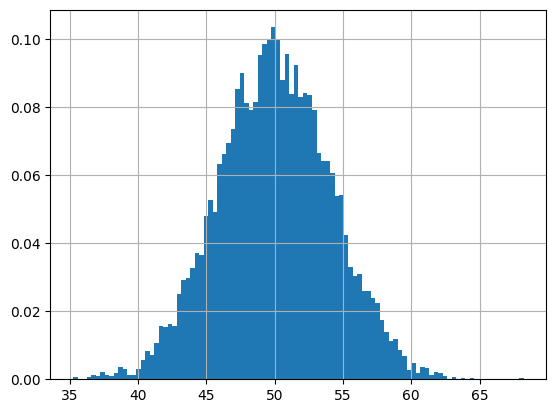

In [11]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist((data + data),bins=100,density=True)
plt.grid(True)
plt.savefig("StatisticsPart04.06.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.06.png**

### Type of Image
Histogram showing a normalized distribution of a doubled‑length normally generated dataset, produced using the `density=True` parameter so that the total area under the bars equals 1.

### Overall Summary
The figure displays a histogram of normally distributed data after the dataset has been doubled in length by concatenation. Because the histogram is computed with `density=True`, the vertical axis reflects probability density rather than raw counts. As a result, the overall bell‑shaped form remains the same as before, and the bar heights stay within the same approximate range, demonstrating that normalization removes the dependence of the vertical scale on dataset size.

### Detailed Description
The x‑axis spans values from roughly 35 to 65. The y‑axis ranges from 0.00 to about 0.10, consistent with normalized density values. The histogram consists of many narrow blue bars forming a smooth, symmetric bell shape centered near 50. The distribution’s height and shape closely match the earlier normalized histogram created from the original dataset, with no visible increase in bar height despite the doubled number of data points. No title, annotations, or overlaid curves appear in the image.

### Purpose of the Image
This image demonstrates that when `density=True` is used, the histogram reflects the *shape* of the distribution independently of dataset length. Doubling the number of data values does not change the vertical scale because the histogram is normalized to unit area. This reinforces why density‑based histograms are preferred when comparing datasets of different sizes or when relating empirical data to theoretical probability density functions.

Good! The shape of the distribution as well as the scale on the vertical axis is now independent of the length of the dataset provided that changing the length doesn't change the distribution.

### The horizontal axis scale

Now let's discuss the meaning of the horizontal scale. 
As you may recall, the dataset contains 10000 values consisting of the average of 50 samples taken from a population of uniformly distributed values between 0 and 100. Although a lot of averaging was done, it is theoretically possible that the dataset could still contain values near 0 or near 100. However, the hist method didn't find any values below about 35 or any values above about 65 for this dataset. (See the tails on the histogram shown above.)

By default, the method ignores everything outside those limits and dedicates the specified number of bins to the values between those limits producing the horizontal scale that you see above. However, we can instruct the method to compute the histogram over any range that we choose through use of the keyword parameter named range. This is illustrated in the following example, which shows the histogram for the same data computed and plotted over the full range from 0 to 100 uniformly spaced bins. Note that the peak still shows the same value on the vertical axis of approximately 0.1.

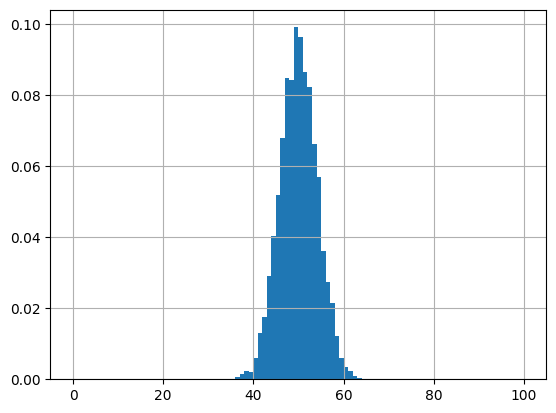

In [12]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)
ax.hist((data + data),bins=100,density=True,range=(0,100))
plt.grid(True)
plt.savefig("StatisticsPart04.07.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.07.png**

### Type of Image
Histogram showing the distribution of averaged sample values.

### Overall Summary
This histogram displays the distribution of 10,000 values, each representing the average of 50 samples drawn from a population uniformly distributed between 0 and 100. Although the underlying population spans the full 0–100 range, the histogram shows that the averaged values cluster tightly around the center, forming a smooth, bell‑shaped pattern.

### Detailed Description
The horizontal axis spans from 0 to 100, while the vertical axis ranges from 0.00 to 0.10. The bars form a symmetric mound centered near 50, with the tallest bars reaching approximately 0.10 on the vertical axis. No bars appear below roughly 35 or above roughly 65, indicating that the dataset contains no values in those outer regions. The overall shape resembles a normal distribution, reflecting the effect of averaging many uniformly distributed samples.

### Purpose of the Image
This figure supports the discussion of how the histogram method determines horizontal axis limits based on the data it receives. It visually demonstrates that, although values near 0 or 100 are theoretically possible, none appear in this dataset, leading the method to restrict the horizontal scale to the observed range by default. The image provides context for explaining how the `range` keyword parameter can be used to override this behavior and force the histogram to span the full 0–100 interval.

### The area under the curve

Now we are prepared to discuss the meaning of the vertical scale that results when the density parameter is set to True. Setting that parameter to True causes the output to be normalized such that the area under the entire curve from 0 through 100 in the above histogram is equal to 1.

We could write code to compute that area if we had access to the values that are plotted in the histogram. As it turns out, we do have access to those values. The hist method returns a tuple containing three things:

1. A list of the values (n) that were plotted.
2. A list of the values (bins) on the horizontal axis for which the values were computed and plotted.
3. Something called a patch having to do with the appearance of the plot.

(At this point, we aren't interested in the patch but if you are interested, you can read about it [here](https://matplotlib.org/api/patches_api.html).)

We are interested in the first item in the list because we can compute the area under the curve in this case by simply adding the values in the list. This is illustrated by the following code which shows the area under the curve to be 1.0.

areaUnderTheCurve = 0.9999999999999998


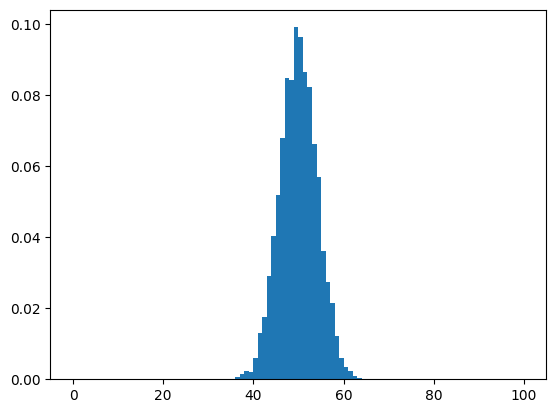

In [13]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)

#Plot the histogram for the data and unpack the tuple that is returned.
n,bins,patches = ax.hist(data,bins=100,density=True,range=(0,100))

#Compute the area under the curve by computing the sum of the values for each of the bins.
areaUnderTheCurve = 0
for val in n:
    areaUnderTheCurve += val
print("areaUnderTheCurve =",areaUnderTheCurve)
plt.savefig("StatisticsPart04.08.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.08.png**

### Type of Image
Histogram displaying a normalized distribution of averaged sample values.

### Overall Summary
This histogram shows the distribution of 10,000 values, each representing the average of 50 samples drawn from a uniform 0–100 population. The histogram was generated with the `density=True` parameter, causing the vertical axis to represent normalized values such that the total area under the curve equals 1. The resulting plot forms a smooth, bell‑shaped pattern centered near 50.

### Detailed Description
The horizontal axis spans from 0 to 100, and the vertical axis ranges from 0.00 to 0.10. The bars form a symmetric mound centered around 50, tapering gradually toward both ends. The tallest bars reach approximately 0.10 on the vertical axis. Because the histogram was computed with `density=True`, the heights of the bars represent relative density rather than raw frequency. The overall shape resembles a normal distribution, reflecting the averaging of many uniformly distributed samples.

### Purpose of the Image
This figure supports the explanation of how the vertical scale changes when the `density` parameter is set to `True`. It visually demonstrates that the histogram is normalized so that the total area under the curve equals 1. The image provides context for discussing how the values returned by the `hist` method—specifically the list of plotted densities—can be summed to verify this normalization.

The situation is a little more difficult to explain when we allow the method to compute and display only a portion of the full histogram. I'm not going to explain the reason why but I will tell you that the sum of the values must be scaled by the ratio of the number of bins displayed to the number of bins specified to cause the result to equal 1.0. This is illustrated in the following code that shows the area under the curve for the full histogram to be 1.0.

binsDisplayed = 33.02108855753568
areaUnderTheCurveForTheFullHistogram  = 0.9999999999999993


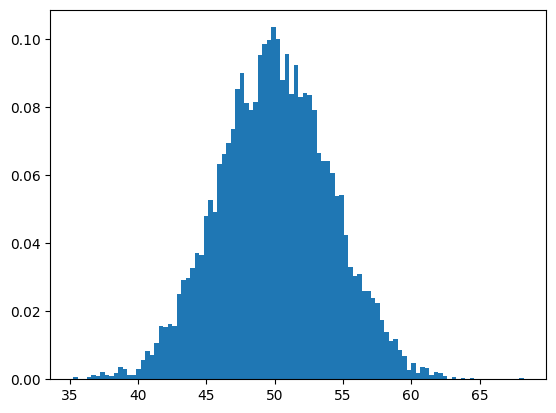

In [14]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)

#Plot the histogram for the data and unpack the tuple that is returned.
n,bins,patches = ax.hist(data,bins=100,density=True)

areaUnderTheCurve  = 0
binsSpecified = 100

#Get the number of bins displayed
binsDisplayed = bins[len(bins)-1] - bins[0]
print("binsDisplayed =",binsDisplayed)

for val in n:
    areaUnderTheCurve  += val
areaUnderTheCurveForTheFullHistogram = areaUnderTheCurve * binsDisplayed/binsSpecified
print("areaUnderTheCurveForTheFullHistogram  =",areaUnderTheCurveForTheFullHistogram)
plt.savefig("StatisticsPart04.09.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.09.png**

### Type of Image
Histogram showing a truncated view of a bell‑shaped distribution.

### Overall Summary
This histogram displays a portion of the distribution of 10,000 averaged sample values, each computed from 50 draws taken from a uniform 0–100 population. Only the central region of the distribution is shown, resulting in a narrower horizontal axis than the full histogram. The visible bars form a smooth, mound‑shaped pattern centered near 50.

### Detailed Description
The horizontal axis spans approximately from 35 to 65, while the vertical axis ranges from 0.00 to 0.10. The bars rise to a peak near the center and taper symmetrically toward both ends of the displayed range. Because only part of the full histogram is shown, the visible bars represent a subset of the bins that would appear if the entire 0–100 range were plotted. The overall shape remains bell‑like, reflecting the distribution of averaged values.

### Purpose of the Image
This figure supports the explanation of how the area under a histogram must be interpreted when only a portion of the full histogram is displayed. It provides visual context for discussing why the sum of the displayed density values must be scaled by the ratio of the number of bins shown to the total number of bins originally specified in order for the computed area to equal 1.0.

### Plot a normal probability density curve on the histogram

Earlier we developed a function named normalProbabilityDensity that can be called to return the values for a normal probability density curve for a given value of mu and a given value of sigma.

The next example creates such a curve for the same mu and sigma as the data and then superimposes that curve on the histogram of the data. As you can see, the histogram of the data is a reasonably good fit to the normal probability density curve.

mu = 50.00627810855217
sigma = 4.106854658585184


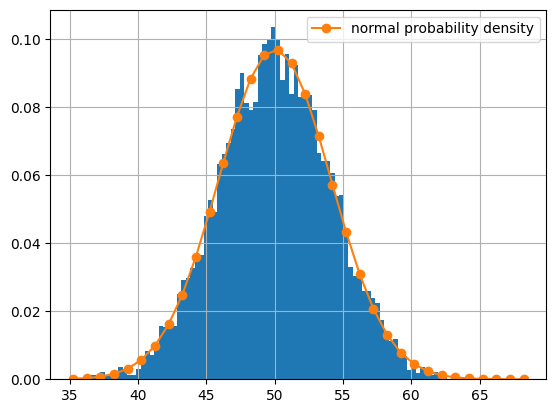

In [15]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)

fig,ax = plt.subplots(1,1)

#Get and print mean and standard deviation of the dataset
xmu = mean(data)
xsigma = stdev(data)
print("mu =",xmu)
print("sigma =",xsigma)

#Plot the histogram for the data and unpack the tuple that is returned.
n,bins,patches = ax.hist(data,bins=100,density=True)

#Compute the values for a normal probability density curve 
# for the same mu and sigma across the same range of values and
# superimpose the normal probability density curve on the histogram.

x = np.arange(bins[0],bins[len(bins)-1],1.0)
y = [normalProbabilityDensity(val,mu=xmu,sigma=xsigma) for val in x]
ax.plot(x,y,label='normal probability density',marker='o')

#Add some cosmetics and show the plot
ax.legend()
ax.grid(True)
plt.savefig("StatisticsPart04.10.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.10.png**

### 1. Type of Image
Histogram with a superimposed normal probability density curve.

### 2. Overall Summary
This image displays a histogram of sample data along with a smooth normal probability density curve plotted on top of it. The curve is generated using the same mean (μ = 50.00627810855217) and standard deviation (σ = 4.106854658585184) as the underlying dataset. The visual comparison helps students evaluate how closely the empirical distribution aligns with a theoretical normal model.

### 3. Detailed Description
The histogram consists of vertical bars representing the frequency of observations across evenly spaced bins. The bars form a roughly symmetric mound shape centered near 50, indicating that most data values cluster around the mean.

Superimposed on the histogram is a continuous, bell‑shaped normal probability density curve. The curve peaks near the same central value as the histogram and tapers smoothly toward both tails. Its height is scaled so that the curve aligns visually with the histogram’s scale, allowing direct comparison between observed frequencies and the theoretical density.

The close alignment between the bars and the curve suggests that the dataset follows a distribution that is reasonably well approximated by a normal distribution with the given parameters.

### 4. Purpose of the Image
The purpose of this image is to illustrate how a normal probability density curve can be plotted on top of a histogram to assess the fit between empirical data and a theoretical normal model. This visualization helps learners understand distributional shape, model assumptions, and the relationship between sample statistics and theoretical parameters.

### Cumulative probability distribution

The hist method can also be called to compute and plot a cumulative probability distribution by setting the keyword paramter named cumulative to True.

The following example plots the cumulative probability distribution of the data and superimposes a cumulative normal probability distribution curve on the data. As you can see, the fit between the two is quite good.

mu = 50.00627810855217
sigma = 4.106854658585184


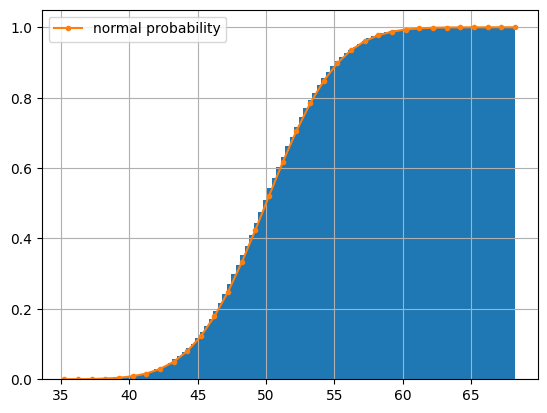

In [16]:
data = normalRandomGenerator(dataLength=10000,numberSamples=50)
fig,ax = plt.subplots(1,1)

#Get and print mean and standard deviation of the dataset
xmu = mean(data)
xsigma = stdev(data)
print("mu =",xmu)
print("sigma =",xsigma)

#Plot the histogram for the data and unpack the tuple that is returned.
n,bins,patches = ax.hist(data,bins=100,density=True,cumulative=True)

#Compute the values for a normal probability density curve for 
# the same mu and sigma across the same range of values.

x = np.arange(bins[0],bins[len(bins)-1],1.0)
y = [cumulativeDistribution((val-xmu)/xsigma) for val in x]
ax.plot(x,y,label='normal probability',marker = '.')

#Add some cosmetics and show the plot
ax.legend()
ax.grid(True)
plt.savefig("StatisticsPart04.11.png")
plt.show()

## **Description of the image shown above, StatisticsPart04.11.png**

### 1. Type of Image
Cumulative histogram with a superimposed cumulative normal probability distribution curve.

### 2. Overall Summary
This image shows the cumulative probability distribution of a dataset plotted using a cumulative histogram. A smooth cumulative normal distribution curve—computed using the dataset’s mean (μ = 50.00627810855217) and standard deviation (σ = 4.106854658585184)—is superimposed on the plot. The close alignment between the empirical cumulative distribution and the theoretical cumulative normal curve demonstrates that the data follow a pattern consistent with a normal distribution.

### 3. Detailed Description
The cumulative histogram rises from left to right in a step‑like fashion, beginning near zero probability and gradually increasing toward one. Each step represents the cumulative proportion of data values falling at or below the corresponding bin boundary. The shape is smooth and S‑shaped, reflecting the underlying distribution of the dataset.

Superimposed on this stepped curve is a continuous cumulative normal distribution curve. This curve begins near zero on the far left, increases gradually through the central region, and approaches one on the far right. Its inflection point occurs near the mean value of the dataset, around 50, where the slope is steepest.

The cumulative histogram and the cumulative normal curve track each other closely across the entire range. Their near‑overlap indicates that the empirical distribution of the data is well approximated by a normal distribution with the given parameters.

### 4. Purpose of the Image
The purpose of this image is to illustrate how cumulative probability distributions can be visualized using both empirical data and theoretical models. By comparing the cumulative histogram to the cumulative normal curve, learners can assess the goodness of fit and deepen their understanding of how cumulative distributions behave for normally distributed data.

## The central limit theorem in action

Now let's look at some examples that show the central limit theorem in action. 

***Note: In order to copy this code and run it under the Python interpreter, you will need to copy and paste the next several sections of code into the same Python source code file. You will also need to dismiss each plot from the screen to cause the next plot to appear.***

### The plotIt function

We will begin by creating a convenience function named plotIt that can produce the desired plot for a given dataset as an input parameter. Then we will apply that function to a series of datasets created by averaging progressively increasing numbers of samples taken from the same population with a uniform distribution.

In [17]:
def plotIt(data):

    fig,ax = plt.subplots(1,1)

    #Get and print mean and standard deviation of the dataset
    xmu = mean(data)
    xsigma = stdev(data)
    print("mu =",xmu)
    print("sigma =",xsigma)

    #Plot the histogram for the data and unpack the tuple that is returned.
    n,bins,patches = ax.hist(data,bins=200,density=True,range=(0,100))

    #Compute the values for a normal probability density curve 
    # for the same mu and sigma across the same range of values and
    # superimpose the normal probability density curve on the histogram.
    
    x = np.arange(bins[0],bins[len(bins)-1],0.25)
    y = [normalProbabilityDensity(val,mu=xmu,sigma=xsigma) for val in x]
    ax.plot(x,y,label='normal probability density')
    
    #Add some cosmetics and show the plot
    ax.legend(loc='lower left')
    ax.grid(True)
    plt.savefig("StatisticsPart04.zzz.png")
    plt.show()

### Uniformly distributed data

We will begin by applying the plotIt function to a dataset of 10000 values taken from a population of uniformly distributed values between 0 and 100. As you can see, the uniform distribution of the data is not a good fit for the normal probability density curve.

Also make note of the sigma for this population as we will be discussing it further later on.

mu = 49.801785158479724
sigma = 29.049719939753082


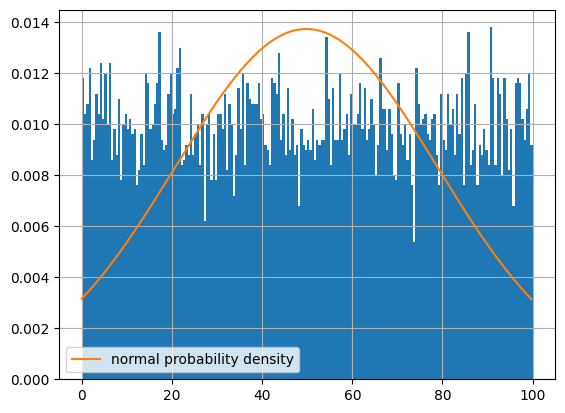

In [18]:
# Create a new dataset of 10000 values taken from a population of uniformly distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=1)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.12.png**

### 1. Type of Image
Histogram of uniformly distributed data with a superimposed normal probability density curve.

### 2. Overall Summary
This image shows the distribution of 10,000 values drawn from a uniform population between 0 and 100. The histogram reveals the flat, rectangular shape characteristic of a uniform distribution. A normal probability density curve—constructed using the dataset’s mean (μ = 49.801785158479724) and standard deviation (σ = 29.049719939753082)—is plotted on top for comparison. The mismatch between the two shapes illustrates that uniformly distributed data do not resemble a normal distribution.

### 3. Detailed Description
The histogram consists of blue bars of roughly equal height across the entire range from 0 to 100, reflecting the constant probability density of a uniform distribution. There is no central peak or tapering toward the tails; instead, the bars form a nearly level plateau.

Superimposed on this is a smooth orange normal probability density curve. The curve rises to a peak near the mean value of approximately 50 and then falls symmetrically toward both ends. Because the normal curve has a bell shape while the histogram is flat, the two do not align. The normal curve sits above the histogram in the center and below it near the edges, highlighting the fundamental difference between the two distributions.

A legend identifies the orange curve as the “normal probability density,” reinforcing the comparison between the empirical uniform data and the theoretical normal model.

### 4. Purpose of the Image
The purpose of this image is to demonstrate that a uniformly distributed dataset does not resemble a normal distribution and therefore does not fit a normal probability density curve. This serves as the starting point for illustrating the central limit theorem: although the raw population is uniform, averaging samples drawn from it will gradually produce distributions that become increasingly normal in shape.

### The average of two samples

Now let's apply the plotIt function to a new dataset of 10000 values containing the average of 2 samples taken from the same population of uniformly distributed values between 0 and 100.

As you can see, the sigma decreased by approximately the square root of two as it should. As you can also see, the distribution of the new dataset has taken on a decidely normal characteristic after averaging only two samples.

mu = 49.984351971052014
sigma = 20.553291369934513


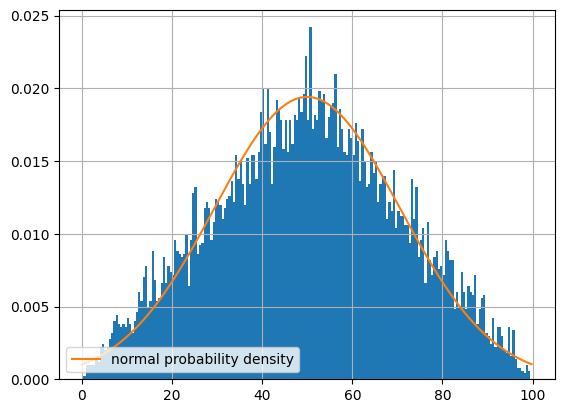

In [19]:
# Create a new dataset of 10000 values consisting of the average of 2 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=2)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.13.png**

### 1. Type of Image
Histogram of averaged uniform‑distribution samples with a superimposed normal probability density curve.

### 2. Overall Summary
This image displays the distribution of 10,000 values created by averaging **two** independent samples drawn from a uniform population between 0 and 100. A normal probability density curve—constructed using the dataset’s mean (μ = 49.984351971052014) and standard deviation (σ = 20.553291369934513)—is plotted on top of the histogram. The visual comparison shows that even averaging only two uniform samples produces a distribution that begins to resemble a normal curve, illustrating the early stages of the central limit theorem in action.

### 3. Detailed Description
The histogram consists of blue bars forming a mound‑shaped distribution centered near 50. Unlike the flat, rectangular shape of the original uniform population, this distribution shows noticeable curvature: the bars rise toward the center and taper toward both ends. The spread of the data is narrower than that of the original population, consistent with the reduction in standard deviation by approximately the square root of two.

Superimposed on the histogram is a smooth orange normal probability density curve. The curve peaks near the dataset’s mean and decreases symmetrically toward the tails. The alignment between the histogram and the curve is visibly closer than in the uniform‑population case, though still not perfect. The histogram’s shape follows the general bell‑curve pattern, demonstrating how averaging even a small number of samples begins to produce normal‑like behavior.

A legend identifies the orange curve as the “normal probability density,” reinforcing the comparison between empirical and theoretical distributions.

### 4. Purpose of the Image
The purpose of this image is to illustrate how the central limit theorem begins to take effect when averaging samples from a uniform distribution. By showing that the average of just two uniform samples already produces a distribution with a noticeably normal shape—and a reduced sigma—this visualization helps learners understand how repeated averaging drives datasets toward normality, even when the underlying population is not normal.

### The average of four samples

The next eight examples show the results of progressively doubling the number of samples averaged into the dataset until finally we end up with a dataset of 10000 values containing the average of 512 samples taken from the same population of uniformly distributed values between 0 and 100.

As you scroll down through these examples, note that sigma decreases by approximately the square root of two with each doubling of the number of samples in the dataset. This is evidenced by the numeric output and also by the fact that the hist method elects to display a narrower and narrower portion of the full histogram with each doubling.

mu = 49.96087303836365
sigma = 14.514947640161623


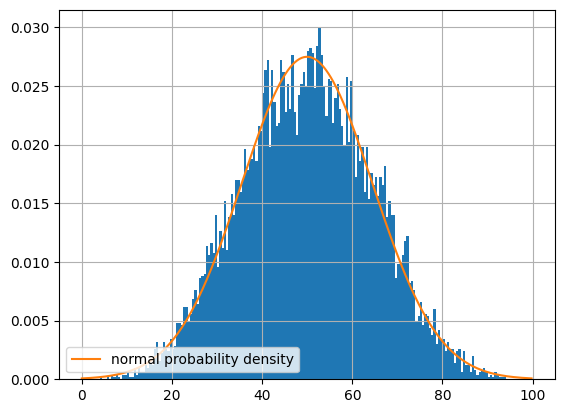

In [20]:
# Create a new dataset of 10000 values consisting of the average of 4 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=4)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.14.png**

### 1. Type of Image
Histogram of averaged uniform‑distribution samples with a superimposed normal probability density curve.

### 2. Overall Summary
This image shows the distribution of 10,000 values created by averaging **four** independent samples drawn from a uniform population between 0 and 100. A normal probability density curve—computed using the dataset’s mean (μ = 49.96087303836365) and standard deviation (σ = 14.514947640161623)—is plotted on top of the histogram. The resulting shape is distinctly bell‑like, demonstrating how quickly the central limit theorem begins to assert itself as more samples are averaged.

### 3. Detailed Description
The histogram is composed of blue bars forming a smooth, symmetric mound centered near 50. Compared with earlier examples using fewer averaged samples, the distribution is noticeably narrower, reflecting the expected reduction in sigma by approximately the square root of two each time the number of averaged samples doubles. The bars rise toward the center and taper gradually toward both tails, closely resembling the curvature of a normal distribution.

Superimposed on the histogram is an orange normal probability density curve. The curve peaks near the dataset’s mean and falls symmetrically toward both ends. The alignment between the histogram and the curve is strong: the bars follow the bell‑shaped contour with only minor deviations. This close match visually reinforces the theoretical prediction that averaging multiple uniform samples produces a distribution that approaches normality.

A legend in the lower left identifies the orange curve as the “normal probability density,” clarifying the comparison between empirical and theoretical distributions.

### 4. Purpose of the Image
The purpose of this image is to illustrate the central limit theorem by showing how the distribution of averaged uniform samples becomes increasingly normal as the number of samples increases. This example, based on averaging four samples, highlights both the narrowing of the distribution and the improved fit to the normal probability density curve, preparing the reader for subsequent examples involving even larger numbers of averaged samples.

### The average of eight samples

mu = 50.06010563283642
sigma = 10.235855014631102


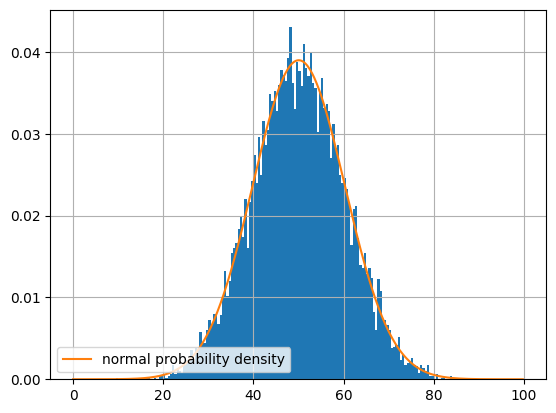

In [21]:
# Create a new dataset of 10000 values consisting of the average of 8 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=8)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.15.png**

### 1. Type of Image
Histogram of averaged uniform‑distribution samples with a superimposed normal probability density curve.

### 2. Overall Summary
This image displays the distribution of 10,000 values created by averaging **eight** independent samples drawn from a uniform population between 0 and 100. A normal probability density curve is plotted on top of the histogram to show how closely the averaged data now resembles a normal distribution. By this stage, the central limit theorem is clearly visible in the shape and narrowing of the distribution.

### 3. Detailed Description
The histogram is composed of blue bars forming a smooth, symmetric mound centered near 50. Compared with the four‑sample case, the distribution is noticeably narrower, reflecting the continued reduction in sigma as the number of averaged samples doubles. The bars rise steeply toward the center and taper cleanly toward both tails, producing a shape that is strongly bell‑like.

Superimposed on the histogram is an orange normal probability density curve. The curve peaks near the dataset’s mean and decreases symmetrically toward both ends. The alignment between the histogram and the curve is very close: the bars follow the curvature of the normal model with only minimal deviations. This strong agreement visually reinforces the central limit theorem’s prediction that averaging multiple uniform samples produces a distribution that approaches normality.

A legend identifies the orange curve as the “normal probability density,” clarifying the comparison between empirical and theoretical distributions.

### 4. Purpose of the Image
The purpose of this image is to demonstrate how the central limit theorem continues to shape the distribution of averaged samples as the number of samples increases. This example, based on averaging eight samples, shows a distribution that is significantly narrower and more normal‑looking than earlier cases, highlighting the progressive convergence toward a normal distribution as averaging continues.

### The average of sixteen samples

mu = 50.04858389060665
sigma = 7.259046779352402


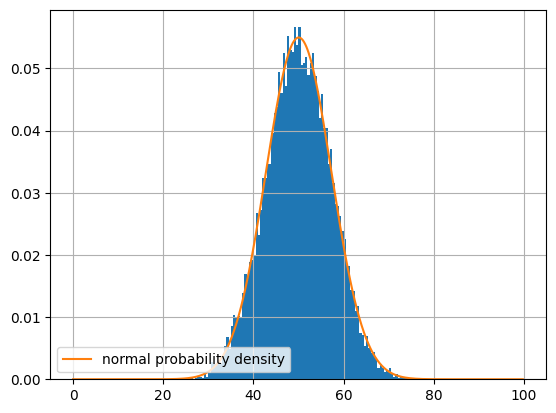

In [22]:
# Create a new dataset of 10000 values consisting of the average of 16 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=16)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.16.png**

### **Type of Image**
Histogram with overlaid normal probability density curve.

### **Overall Summary**
This figure shows the sampling distribution of the sample mean for n = 16, illustrating the early stages of convergence toward a normal shape.

### **Detailed Description**
The histogram displays simulated sample means for n = 16. The distribution is somewhat variable but already shows increasing symmetry and a closer alignment with the superimposed normal curve compared to smaller sample sizes.

### **Purpose of the Image**
To demonstrate how the sampling distribution of the mean becomes more stable and more closely approximates a normal distribution as sample size increases.

### The average of 32 samples

mu = 50.01598009926033
sigma = 5.149117700629042


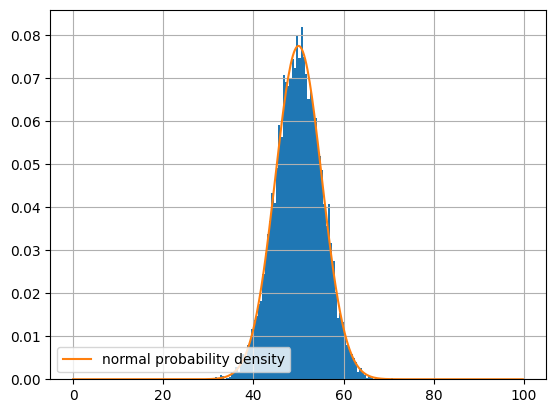

In [23]:
# Create a new dataset of 10000 values consisting of the average of 32 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=32)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.17.png**

### **Type of Image**
Histogram with overlaid normal probability density curve.

### **Overall Summary**
This figure shows the sampling distribution of the sample mean for n = 32, displaying a noticeably smoother and more symmetric shape.

### **Detailed Description**
The histogram presents simulated sample means for n = 32. The distribution is narrower and more regular than at smaller sample sizes, aligning more closely with the superimposed normal curve.

### **Purpose of the Image**
To illustrate how increasing the sample size improves the stability and normality of the sampling distribution of the mean.

### The average of 64 samples

mu = 50.02487106929253
sigma = 3.597019328061025


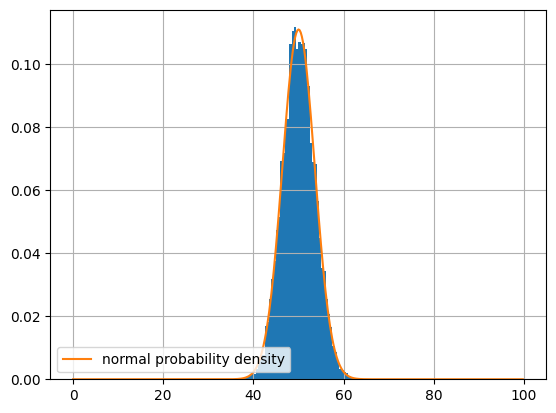

In [24]:
# Create a new dataset of 10000 values consisting of the average of 64 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=64)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.18.png**

### **Type of Image**
Histogram with overlaid normal probability density curve.

### **Overall Summary**
This figure shows the sampling distribution of the sample mean for n = 64, now appearing smooth, symmetric, and tightly concentrated.

### **Detailed Description**
The histogram displays simulated sample means for n = 64. The distribution is noticeably narrower and aligns closely with the superimposed normal curve, reflecting reduced variability and stronger normal approximation.

### **Purpose of the Image**
To demonstrate how a larger sample size produces a sampling distribution that is highly stable and closely matches the normal model.

### The average of 128 samples

mu = 50.00256987947287
sigma = 2.5439179950418715


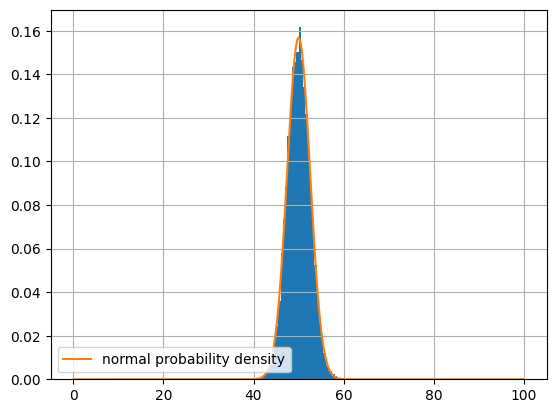

In [25]:
# Create a new dataset of 10000 values consisting of the average of 128 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=128)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.19.png**

### **Type of Image**
Histogram with overlaid normal probability density curve.

### **Overall Summary**
This figure shows the sampling distribution of the sample mean for n = 128, which now appears very smooth, symmetric, and tightly concentrated around the center.

### **Detailed Description**
The histogram presents simulated sample means for n = 128. The distribution is narrow and highly regular, with the bars closely matching the shape of the superimposed normal curve, reflecting strong convergence to normality.

### **Purpose of the Image**
To illustrate that with a sufficiently large sample size, the sampling distribution of the mean becomes extremely stable and nearly indistinguishable from the normal model.

### The average of 256 samples

mu = 50.00397299111193
sigma = 1.7904633206250304


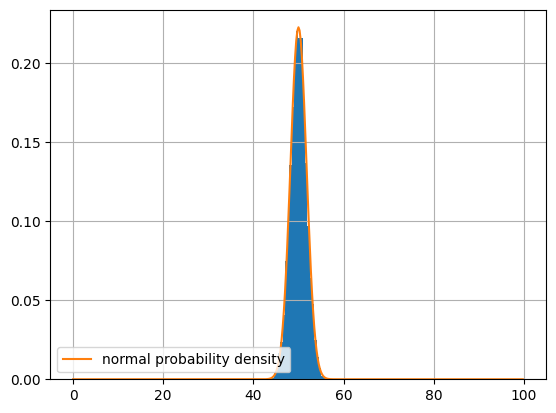

In [26]:
# Create a new dataset of 10000 values consisting of the average of 256 samples taken from a population of uniformly
# distributed values between 0 and 100.
data = normalRandomGenerator(dataLength=10000,numberSamples=256)
    
plotIt(data)

## **Description of the image shown above, StatisticsPart04.20.png**

### **Type of Image**
Histogram with overlaid normal probability density curve.

### **Overall Summary**
This figure shows the sampling distribution of the sample mean for n = 256, which is now extremely smooth, symmetric, and tightly concentrated.

### **Detailed Description**
The histogram presents simulated sample means for n = 256. The distribution is very narrow and aligns almost perfectly with the superimposed normal curve, reflecting strong convergence and minimal sampling variability.

### **Purpose of the Image**
To demonstrate that with a large sample size, the sampling distribution of the mean becomes highly stable and nearly identical to the normal model predicted by the Central Limit Theorem.

### The average of 512 samples

mu = 49.98389212033013
sigma = 1.264458435829136


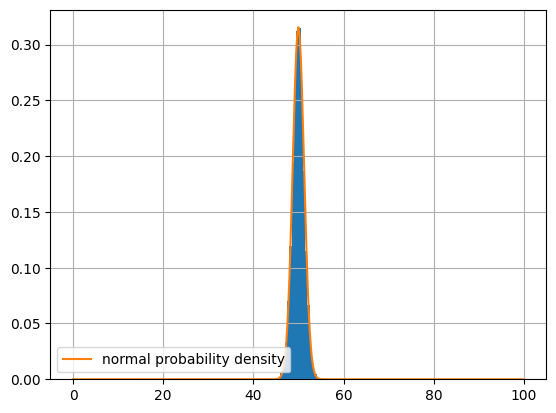

In [27]:
data = normalRandomGenerator(dataLength=10000,numberSamples=512)
plotIt(data)

## **Description of the image shown above, StatisticsPart04.21.png**

### **Type of Image**
Histogram of averaged uniform-distribution samples with a superimposed normal probability density curve, displayed over the full 0–100 range and rendered with 200 bins to produce an exceptionally smooth, nearly continuous appearance.

### **Overall Summary**
This figure presents the sampling distribution of the sample mean for n = 512, based on 10,000 simulated averages drawn from a uniform 0–100 population. The resulting shape is a sharply concentrated mound centered near 50, with the normal probability density curve matching it so closely that the two are almost indistinguishable.

### **Detailed Description**
The histogram consists of very narrow blue bars, each representing one of 200 bins across the 0–100 range. Because the sample size is large and the number of bins is high, the bars blend visually into a smooth, continuous‑looking distribution. The histogram occupies only a small central portion of the horizontal axis, making the shrinking standard deviation unmistakable.

The superimposed orange normal probability density curve overlays the histogram with near‑perfect alignment. The curve rises steeply to a narrow peak at the mean and falls symmetrically on both sides. At this level of smoothing, the viewer can see that the empirical distribution of the sample mean has converged almost exactly to the theoretical normal model predicted by the central limit theorem.

The 0–100 range reinforces the dramatic contrast between the wide, flat uniform population and the extremely narrow distribution of the sample mean. The histogram’s width is only a tiny fraction of the original population’s spread, visually demonstrating the $\frac{1}{\sqrt{n}}$ reduction in standard deviation.

### **Purpose of the Image**
This image serves as the final, polished illustration of the central limit process. By combining a large sample size (n = 512), a large number of simulated averages, and a high‑resolution histogram with 200 bins, the figure makes the convergence to normality visually undeniable. It also highlights the profound reduction in variability that occurs when many independent observations are averaged.

As the concluding image in this sequence, it brings the entire story together:

- The underlying population is uniform, not normal.  
- Small samples produce wide, irregular, and sometimes lumpy sampling distributions.  
- As sample size increases, the distribution becomes smoother, more symmetric, and more tightly concentrated.  
- With sufficiently large n, the sampling distribution of the mean becomes almost perfectly normal, with a standard deviation far smaller than that of the original population.

This final figure provides a clear, intuitive, and visually compelling demonstration of the central limit theorem in action. It prepares the reader to move from visualization to application—using the normal model for inference about means, even when the underlying population is far from normal.

## Summary
As we conclude the final part of these statistics exercises, the progression of visualizations has shown how several foundational ideas in statistics fit together into a coherent story. 

We began with the basics of histograms—simple yet powerful tools for revealing the shape of a dataset—and saw how adjusting the density and range settings changes the way information is expressed. 

From there, the cumulative probability distribution offered a complementary perspective, allowing us to track how probability accumulates across the domain. 

Layer by layer, these tools prepared us for the central limit theorem, whose influence became unmistakable as we averaged larger and larger samples. What began as a wide, flat uniform distribution gradually transformed into a smooth, sharply focused, nearly perfect normal curve. 

By the time we reached 512 samples, the sampling distribution of the mean had become so stable and so narrow that the original population’s shape was almost irrelevant. Together, these concepts illustrate one of the most remarkable truths in statistics: that order, predictability, and normality emerge naturally from randomness when we view data through the lens of averaging.

Author: Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: StatisticsPart04.ipynb

Revised: 03/09/2026

Copyright 2018 Richard G. Baldwin

-end-